# Visualizing On- and Off-Morphology Signatures

This notebook visualizes UMAP embeddings projected through the **on-morphology signature** (disease-relevant features) and **off-morphology signature** (non-specific features) to assess whether each signature separates healthy from failing cardiac fibroblasts.

Perturbations:
- **DMSO**: Negative control
- **TGFβRi**: Positive control

In [1]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(arrow)
    library(jsonlite)
    library(ggplot2)
    library(patchwork)
    library(scales)
    library(umap)
    library(magick)
    library(dplyr)
    library(RColorBrewer)
})

## Plotting Configuration

Global `ggplot2` theme, axis styling, and color palette used across all plots.

In [2]:
# Set random seed for reproducibility
set.seed(0)

# ggplot configuration
theme_set(
    theme_minimal(base_size = 16, base_family = "sans") +
    theme(
        # Axis styling
        axis.line = element_line(color = "black", linewidth = 0.5),
        axis.ticks = element_line(color = "black", linewidth = 0.5),
        axis.text = element_text(color = "black", size = 13),
        axis.title = element_text(face = "bold", size = 14),
        
        # Panel styling
        panel.grid.major = element_line(color = "grey90", linewidth = 0.25),
        panel.grid.minor = element_blank(),
        panel.background = element_rect(fill = "white", color = NA),
        panel.border = element_blank(),
        
        # Plot styling
        plot.title = element_text(face = "bold", size = 17, hjust = 0.5),
        plot.subtitle = element_text(size = 13, hjust = 0.5, color = "grey40"),
        plot.background = element_rect(fill = "white", color = NA),
        
        # Legend styling
        legend.position = "none",
        legend.title = element_text(face = "bold", size = 17),
        legend.text = element_text(size = 16),
        legend.background = element_rect(fill = "white", color = NA), # Change color to NA
        legend.key = element_blank(),
        
        # Strip styling for facets
        strip.text = element_text(face = "bold", size = 14),
        strip.background = element_rect(fill = "grey95", color = "grey80")
    )
)

# color palette - using Dark2 from RColorBrewer
# Get the number of unique cell_treatment combinations
color_palette <- brewer.pal(8, "Dark2")

## Data Paths

Input directories for pre-computed UMAP results and output directory for saved figures.

In [3]:
# Define directory paths
module_results_dir <- file.path("..", "results")
figures_dir <- file.path(".", "figures")

# Input paths for pre-computed PCA and UMAP results
umap_dir <- file.path(module_results_dir, "umap")

# UMAP file paths
umap_on_path <- file.path(umap_dir, "cfret_pilot_on_morph_umap.parquet")
umap_off_path <- file.path(umap_dir, "cfret_pilot_off_morph_umap.parquet")
umap_all_path <- file.path(umap_dir, "cfret_pilot_all_morph_umap.parquet")

# Verify files exist
if (!file.exists(umap_on_path)) stop("UMAP on-target file not found")
if (!file.exists(umap_off_path)) stop("UMAP off-target file not found")
if (!file.exists(umap_all_path)) stop("UMAP all-target file not found")

In [4]:
# Create figures directory
dir.create(figures_dir, showWarnings = FALSE, recursive = TRUE)

cat("Figures directory created at:", figures_dir, "\n")

Figures directory created at: ./figures 


### Overlay Comparison

All perturbations are shown on the same axes for a high-level view of population separation in UMAP space.

In [5]:
# Plot dimensions (in inches)
plot_width_combined <- 12
plot_height_combined <- 5.5
plot_width_faceted <- 10
plot_height_faceted <- 9

# Point styling
point_alpha <- 0.3
point_size <- 1.5
point_shape <- 16  # filled circle

# Faceted plot styling
facet_point_alpha <- 0.4
facet_point_size <- 1.2

# Legend styling
legend_alpha <- 1
legend_size <- 3

# Resolution for rendering
render_dpi <- 300

## UMAP Visualization

UMAP is a non-linear dimensionality reduction technique that preserves local neighborhood structure. We use it to assess whether the on-morphology signature creates distinct clusters for healthy vs. failing cells.

### Load UMAP Data

Load pre-computed UMAP coordinates and prepare perturbation labels for plotting.

In [6]:
# Load pre-computed UMAP results
umap_on_df <- read_parquet(umap_on_path)
umap_off_df <- read_parquet(umap_off_path)
umap_all_df <- read_parquet(umap_all_path)

# Ensure a perturbation column is available (new schema)
ensure_perturbation_col <- function(df) {
    if ("Metadata_perturbation" %in% names(df)) {
        return(df)
    }

    if (all(c("Metadata_cell_type", "Metadata_treatment") %in% names(df))) {
        return(df %>% mutate(Metadata_perturbation = paste(Metadata_cell_type, Metadata_treatment, sep = "_")))
    }

    stop("Could not find Metadata_perturbation or legacy columns to construct it")
}

umap_on_df <- ensure_perturbation_col(umap_on_df)
umap_off_df <- ensure_perturbation_col(umap_off_df)
umap_all_df <- ensure_perturbation_col(umap_all_df)

# Display structure
cat("UMAP ON shape:", nrow(umap_on_df), "x", ncol(umap_on_df), "\n")
cat("UMAP OFF shape:", nrow(umap_off_df), "x", ncol(umap_off_df), "\n")
cat("UMAP ALL shape:", nrow(umap_all_df), "x", ncol(umap_all_df), "\n")

# Display cell counts by perturbation
cell_counts_umap <- umap_on_df %>%
    count(Metadata_perturbation, name = "n_cells")

cat("\nCell counts by perturbation:\n")
print(cell_counts_umap)

# Verify required columns exist
required_umap_cols <- c("UMAP1", "UMAP2", "Metadata_perturbation")
if (!all(required_umap_cols %in% names(umap_on_df))) {
    stop("Required columns missing in UMAP data")
}

cat("\nUMAP data loaded successfully\n")

UMAP ON shape: 15793 x 23 
UMAP OFF shape: 15793 x 23 
UMAP ALL shape: 15793 x 23 

Cell counts by perturbation:
# A tibble: 4 × 2
  Metadata_perturbation n_cells
  <chr>                   <int>
1 failing_DMSO             9153
2 failing_TGFRi            3788
3 healthy_DMSO             1366
4 healthy_TGFRi            1486

UMAP data loaded successfully


### UMAP Overlay Comparison

On-morphology (left) and off-morphology (right) signatures shown side by side. Clearer separation between perturbation conditions in the on-morphology panel indicates it captures disease-relevant variation.

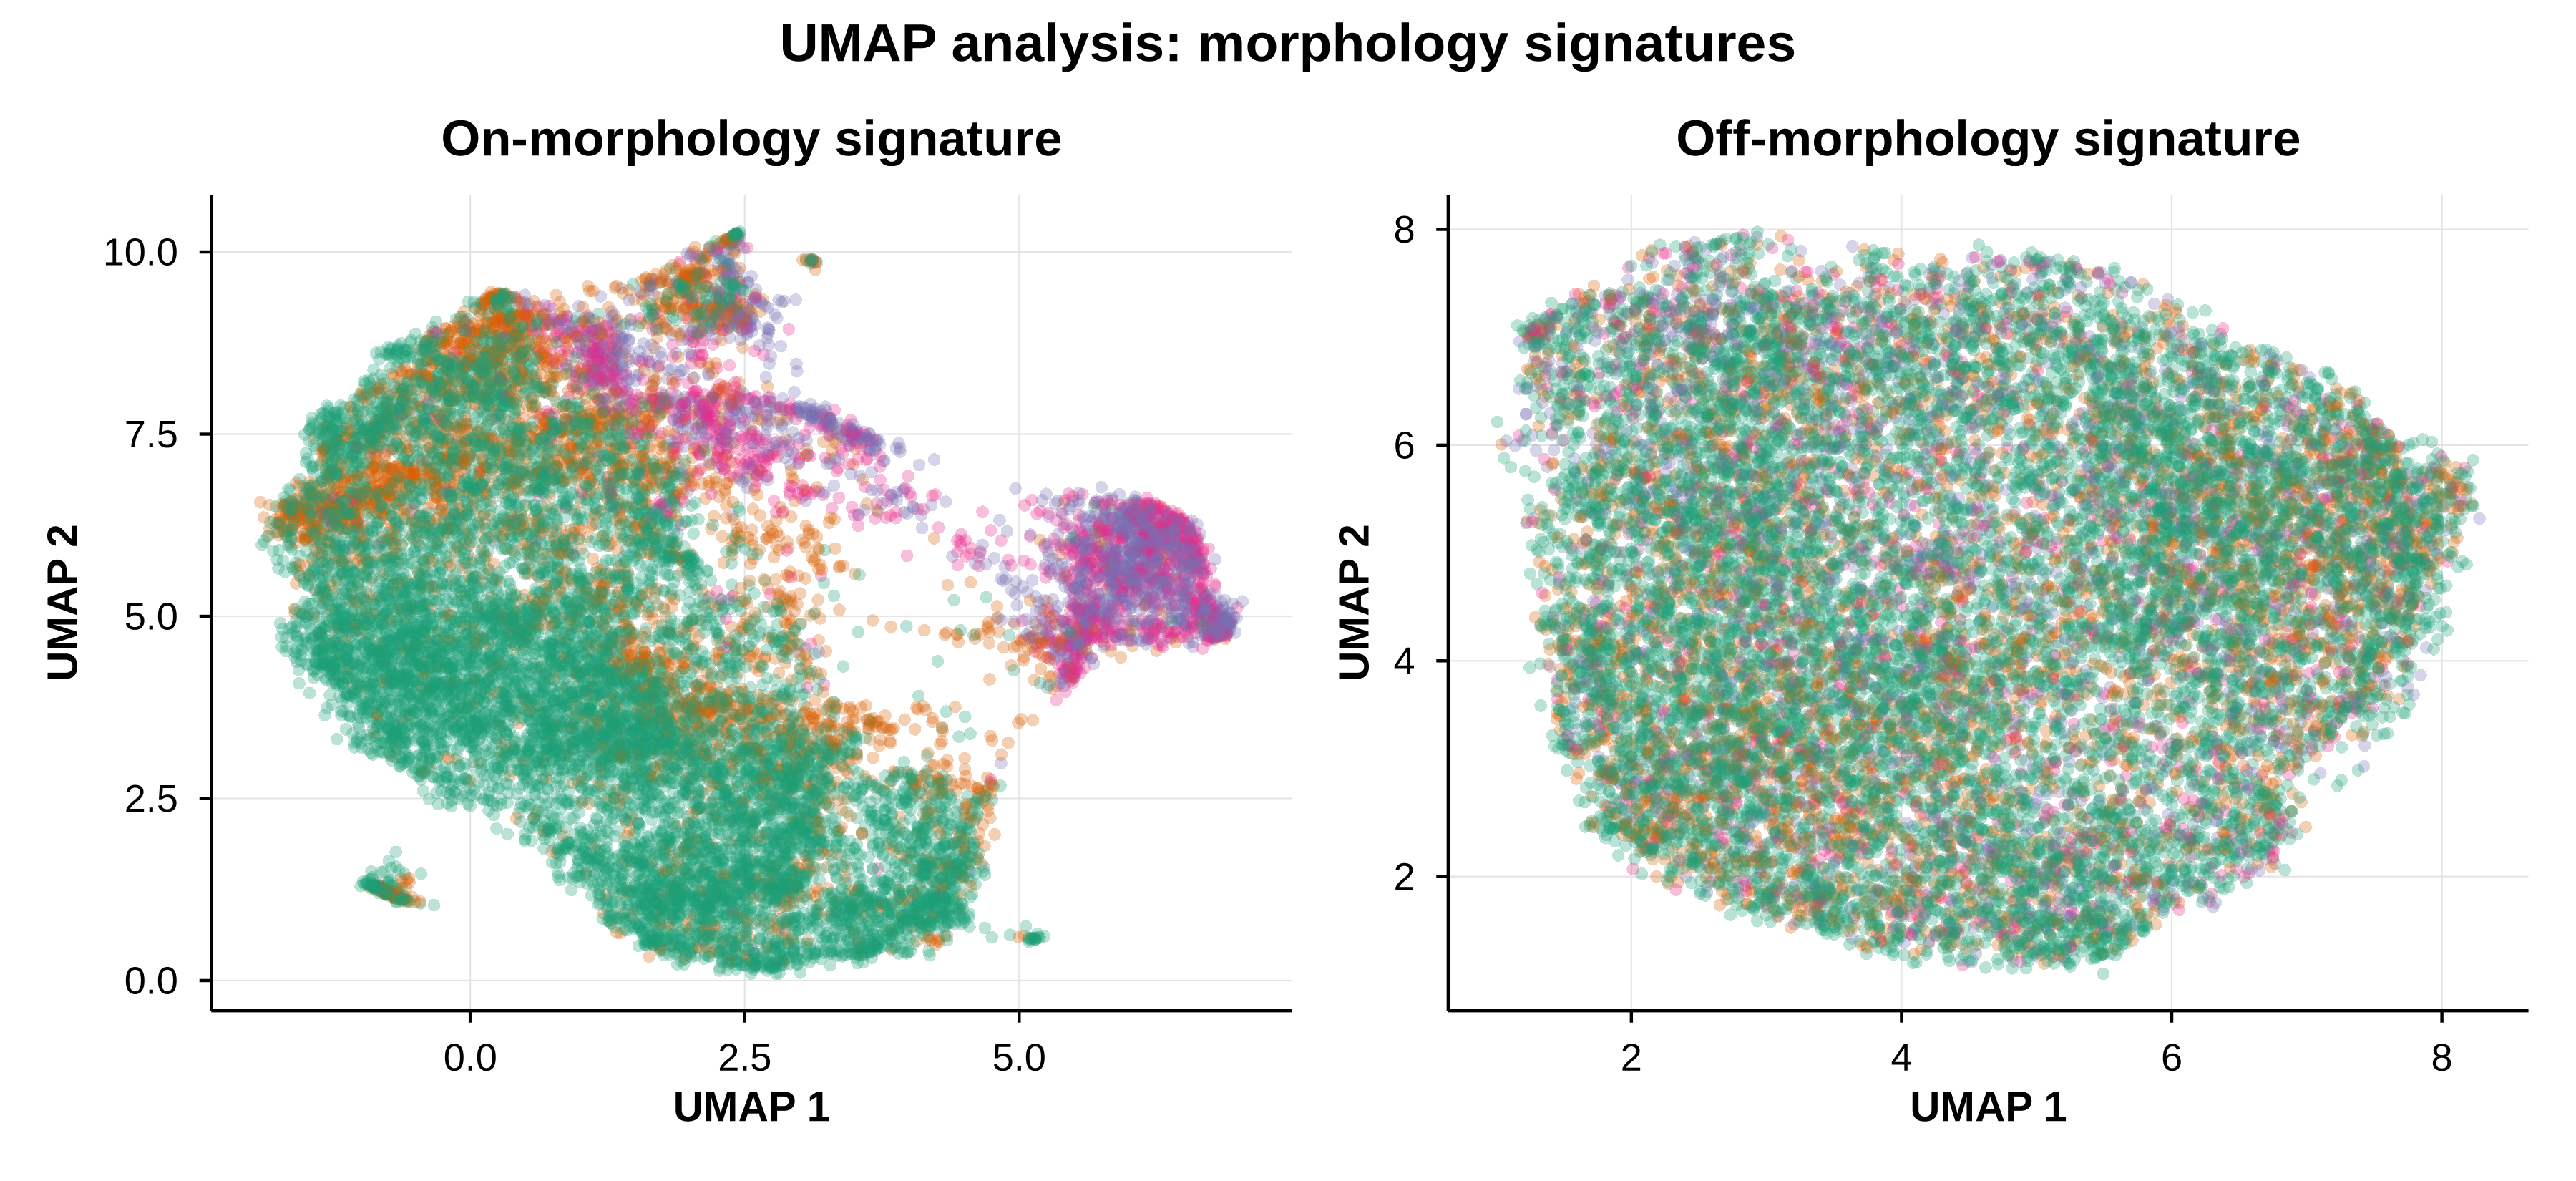

In [7]:
# Define perturbation order and display labels
perturbation_levels <- c("failing_DMSO", "failing_TGFRi", "healthy_TGFRi", "healthy_DMSO")
perturbation_labels <- c(
    failing_DMSO = "Failing DMSO",
    failing_TGFRi = "Failing TGFβRi",
    healthy_TGFRi = "Healthy TGFβRi",
    healthy_DMSO = "Healthy DMSO"
)

umap_on_df_plot <- umap_on_df %>%
    mutate(Metadata_perturbation = factor(Metadata_perturbation, levels = perturbation_levels))

umap_off_df_plot <- umap_off_df %>%
    mutate(Metadata_perturbation = factor(Metadata_perturbation, levels = perturbation_levels))

# Create on-morphology signature UMAP plot
plot_umap_on <- ggplot(umap_on_df_plot, aes(x = UMAP1, y = UMAP2, color = Metadata_perturbation)) +
    geom_point(alpha = point_alpha, size = point_size, shape = point_shape) +
    scale_color_manual(
        values = color_palette,
        breaks = perturbation_levels,
        labels = unname(perturbation_labels[perturbation_levels]),
        name = "Perturbation"
    ) +
    labs(
        title = "On-morphology signature",
        x = "UMAP 1",
        y = "UMAP 2"
    ) +
    guides(color = guide_legend(override.aes = list(alpha = legend_alpha, size = legend_size)))

# Create off-morphology signature UMAP plot
plot_umap_off <- ggplot(umap_off_df_plot, aes(x = UMAP1, y = UMAP2, color = Metadata_perturbation)) +
    geom_point(alpha = point_alpha, size = point_size, shape = point_shape) +
    scale_color_manual(
        values = color_palette,
        breaks = perturbation_levels,
        labels = unname(perturbation_labels[perturbation_levels]),
        name = "Perturbation"
    ) +
    labs(
        title = "Off-morphology signature",
        x = "UMAP 1",
        y = "UMAP 2"
    ) +
    guides(color = guide_legend(override.aes = list(alpha = legend_alpha, size = legend_size)))

# Combine plots using patchwork
umap_combined <- plot_umap_on + plot_umap_off +
    plot_layout(guides = "collect") +
    plot_annotation(
        title = "UMAP analysis: morphology signatures",
        theme = theme(plot.title = element_text(face = "bold", size = 18, hjust = 0.5))
    )

# Display plot
options(repr.plot.width = plot_width_combined, repr.plot.height = plot_height_combined, repr.plot.res = render_dpi)
print(umap_combined)

Colors represent each perturbation (Failing DMSO, Failing TGFβRi, Healthy TGFβRi, Healthy DMSO). The left panel shows the on-morphology signature and the right shows the off-morphology signature. Tighter, more separated clusters in the on-morphology panel indicate it better captures disease-relevant phenotypic differences.

In [8]:
# Save UMAP overlay comparison
ggsave(
    filename = file.path(figures_dir, "umap_on_off_comparison.png"),
    plot = umap_combined,
    width = plot_width_combined,
    height = plot_height_combined,
    dpi = render_dpi,
    bg = "white"
)
cat("Saved UMAP overlay plots to:", figures_dir, "\n")

Saved UMAP overlay plots to: ./figures 


### Faceted UMAP Visualization

UMAP plots split by perturbation to examine each group's distribution without overlapping points.

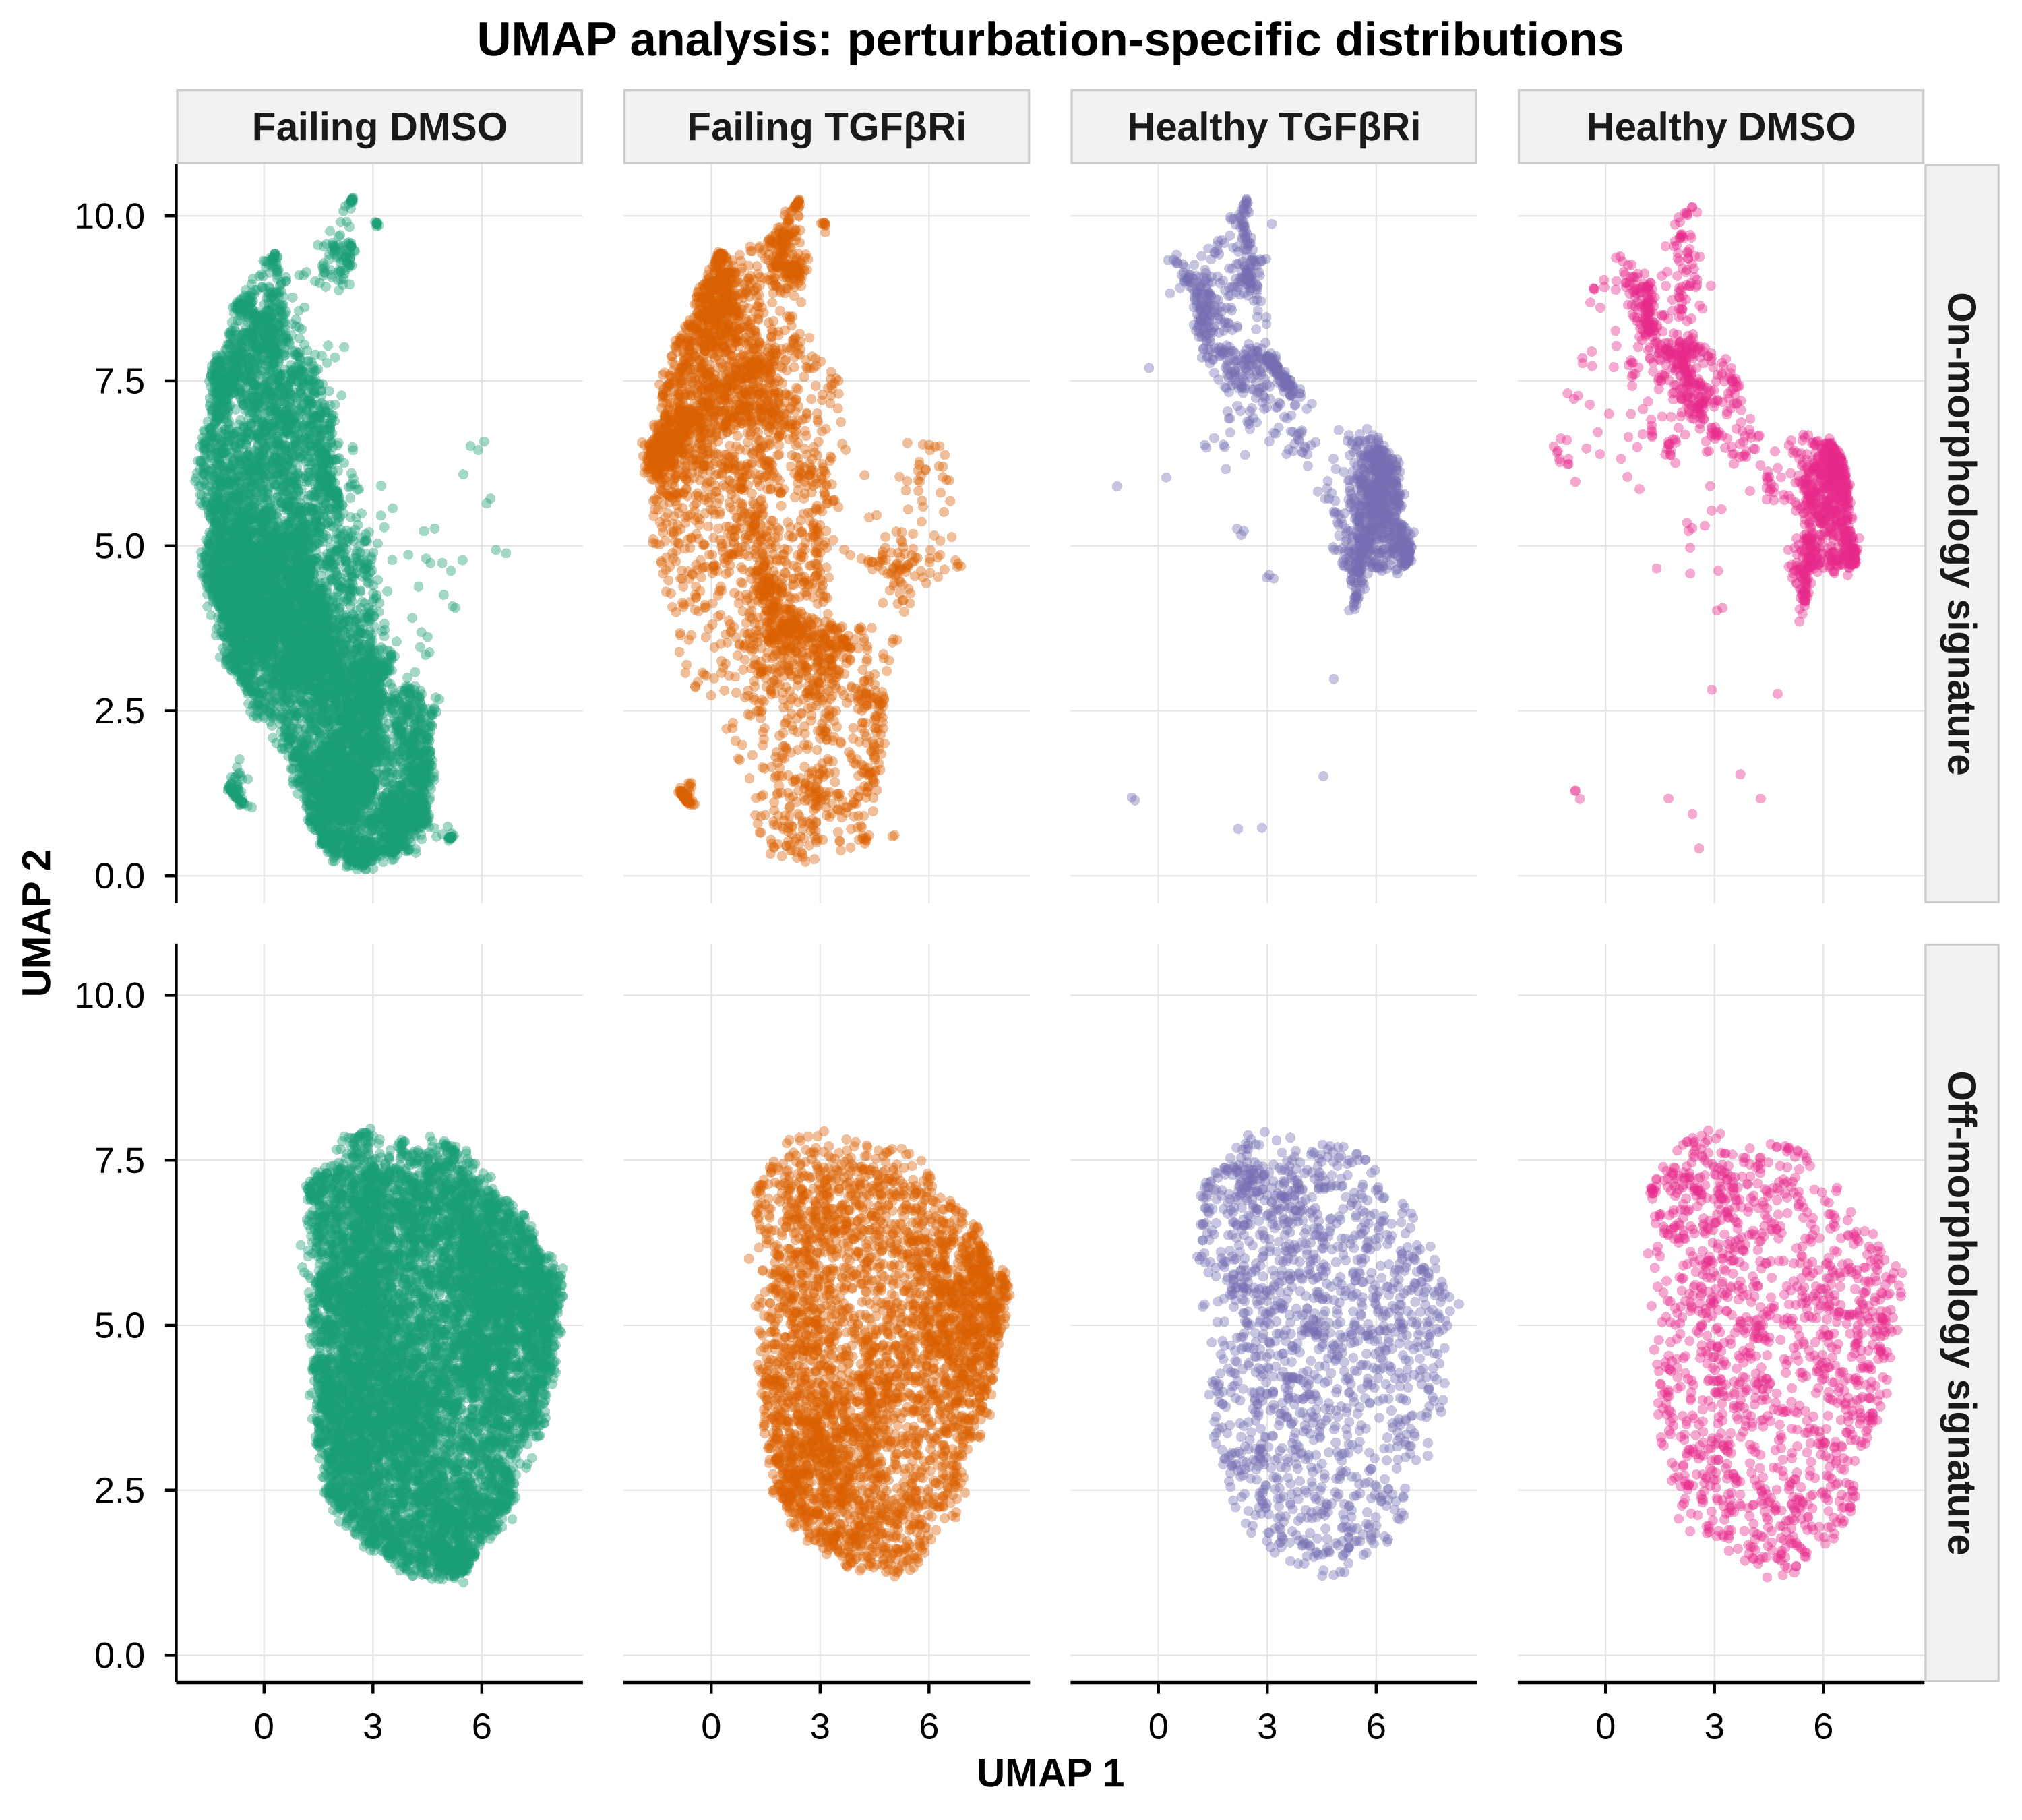

In [9]:
# Define perturbation order and display labels
perturbation_levels <- c("failing_DMSO", "failing_TGFRi", "healthy_TGFRi", "healthy_DMSO")
perturbation_labels <- c(
    failing_DMSO = "Failing DMSO",
    failing_TGFRi = "Failing TGFβRi",
    healthy_TGFRi = "Healthy TGFβRi",
    healthy_DMSO = "Healthy DMSO"
)

# Prepare data for faceting
umap_on_df_facet <- umap_on_df %>%
    mutate(signature_type = "On-morphology signature")

umap_off_df_facet <- umap_off_df %>%
    mutate(signature_type = "Off-morphology signature")

# Create faceted UMAP plot
umap_faceted <- bind_rows(umap_on_df_facet, umap_off_df_facet) %>%
    mutate(
        signature_type = factor(signature_type, levels = c("On-morphology signature", "Off-morphology signature")),
        Metadata_perturbation = factor(Metadata_perturbation, levels = perturbation_levels)
    ) %>%
    ggplot(aes(x = UMAP1, y = UMAP2, color = Metadata_perturbation)) +
    geom_point(alpha = facet_point_alpha, size = facet_point_size, shape = point_shape) +
    scale_color_manual(
        values = color_palette,
        breaks = perturbation_levels,
        labels = unname(perturbation_labels[perturbation_levels]),
        name = "Perturbation"
    ) +
    facet_grid(
        signature_type ~ Metadata_perturbation,
        labeller = labeller(Metadata_perturbation = perturbation_labels)
    ) +
    labs(
        title = "UMAP analysis: perturbation-specific distributions",
        x = "UMAP 1",
        y = "UMAP 2"
    ) +
    guides(color = guide_legend(override.aes = list(alpha = legend_alpha, size = legend_size))) +
    theme(
        strip.text = element_text(face = "bold", size = 14),
        panel.spacing = unit(1, "lines")
    )

# Display plot
options(repr.plot.width = plot_width_faceted, repr.plot.height = plot_height_faceted, repr.plot.res = render_dpi)
print(umap_faceted)

Columns correspond to perturbations; rows correspond to signature type (on-morphology top, off-morphology bottom). The on-morphology signature shows clear separation between healthy and failing cells. The off-morphology signature shows more overlap, confirming it captures non-specific variation rather than disease-relevant phenotypes.

In [10]:
# Save UMAP faceted plot
ggsave(
    filename = file.path(figures_dir, "umap_facet_grid.png"),
    plot = umap_faceted,
    width = plot_width_faceted,
    height = plot_height_faceted,
    dpi = render_dpi,
    bg = "white"
)

cat("Saved UMAP faceted plots to:", figures_dir, "\n")

Saved UMAP faceted plots to: ./figures 


### UMAP Density Plots (KDE)

2D Kernel Density Estimation (KDE) contours overlaid on scatter points to highlight population density and sub-population structure within each perturbation.

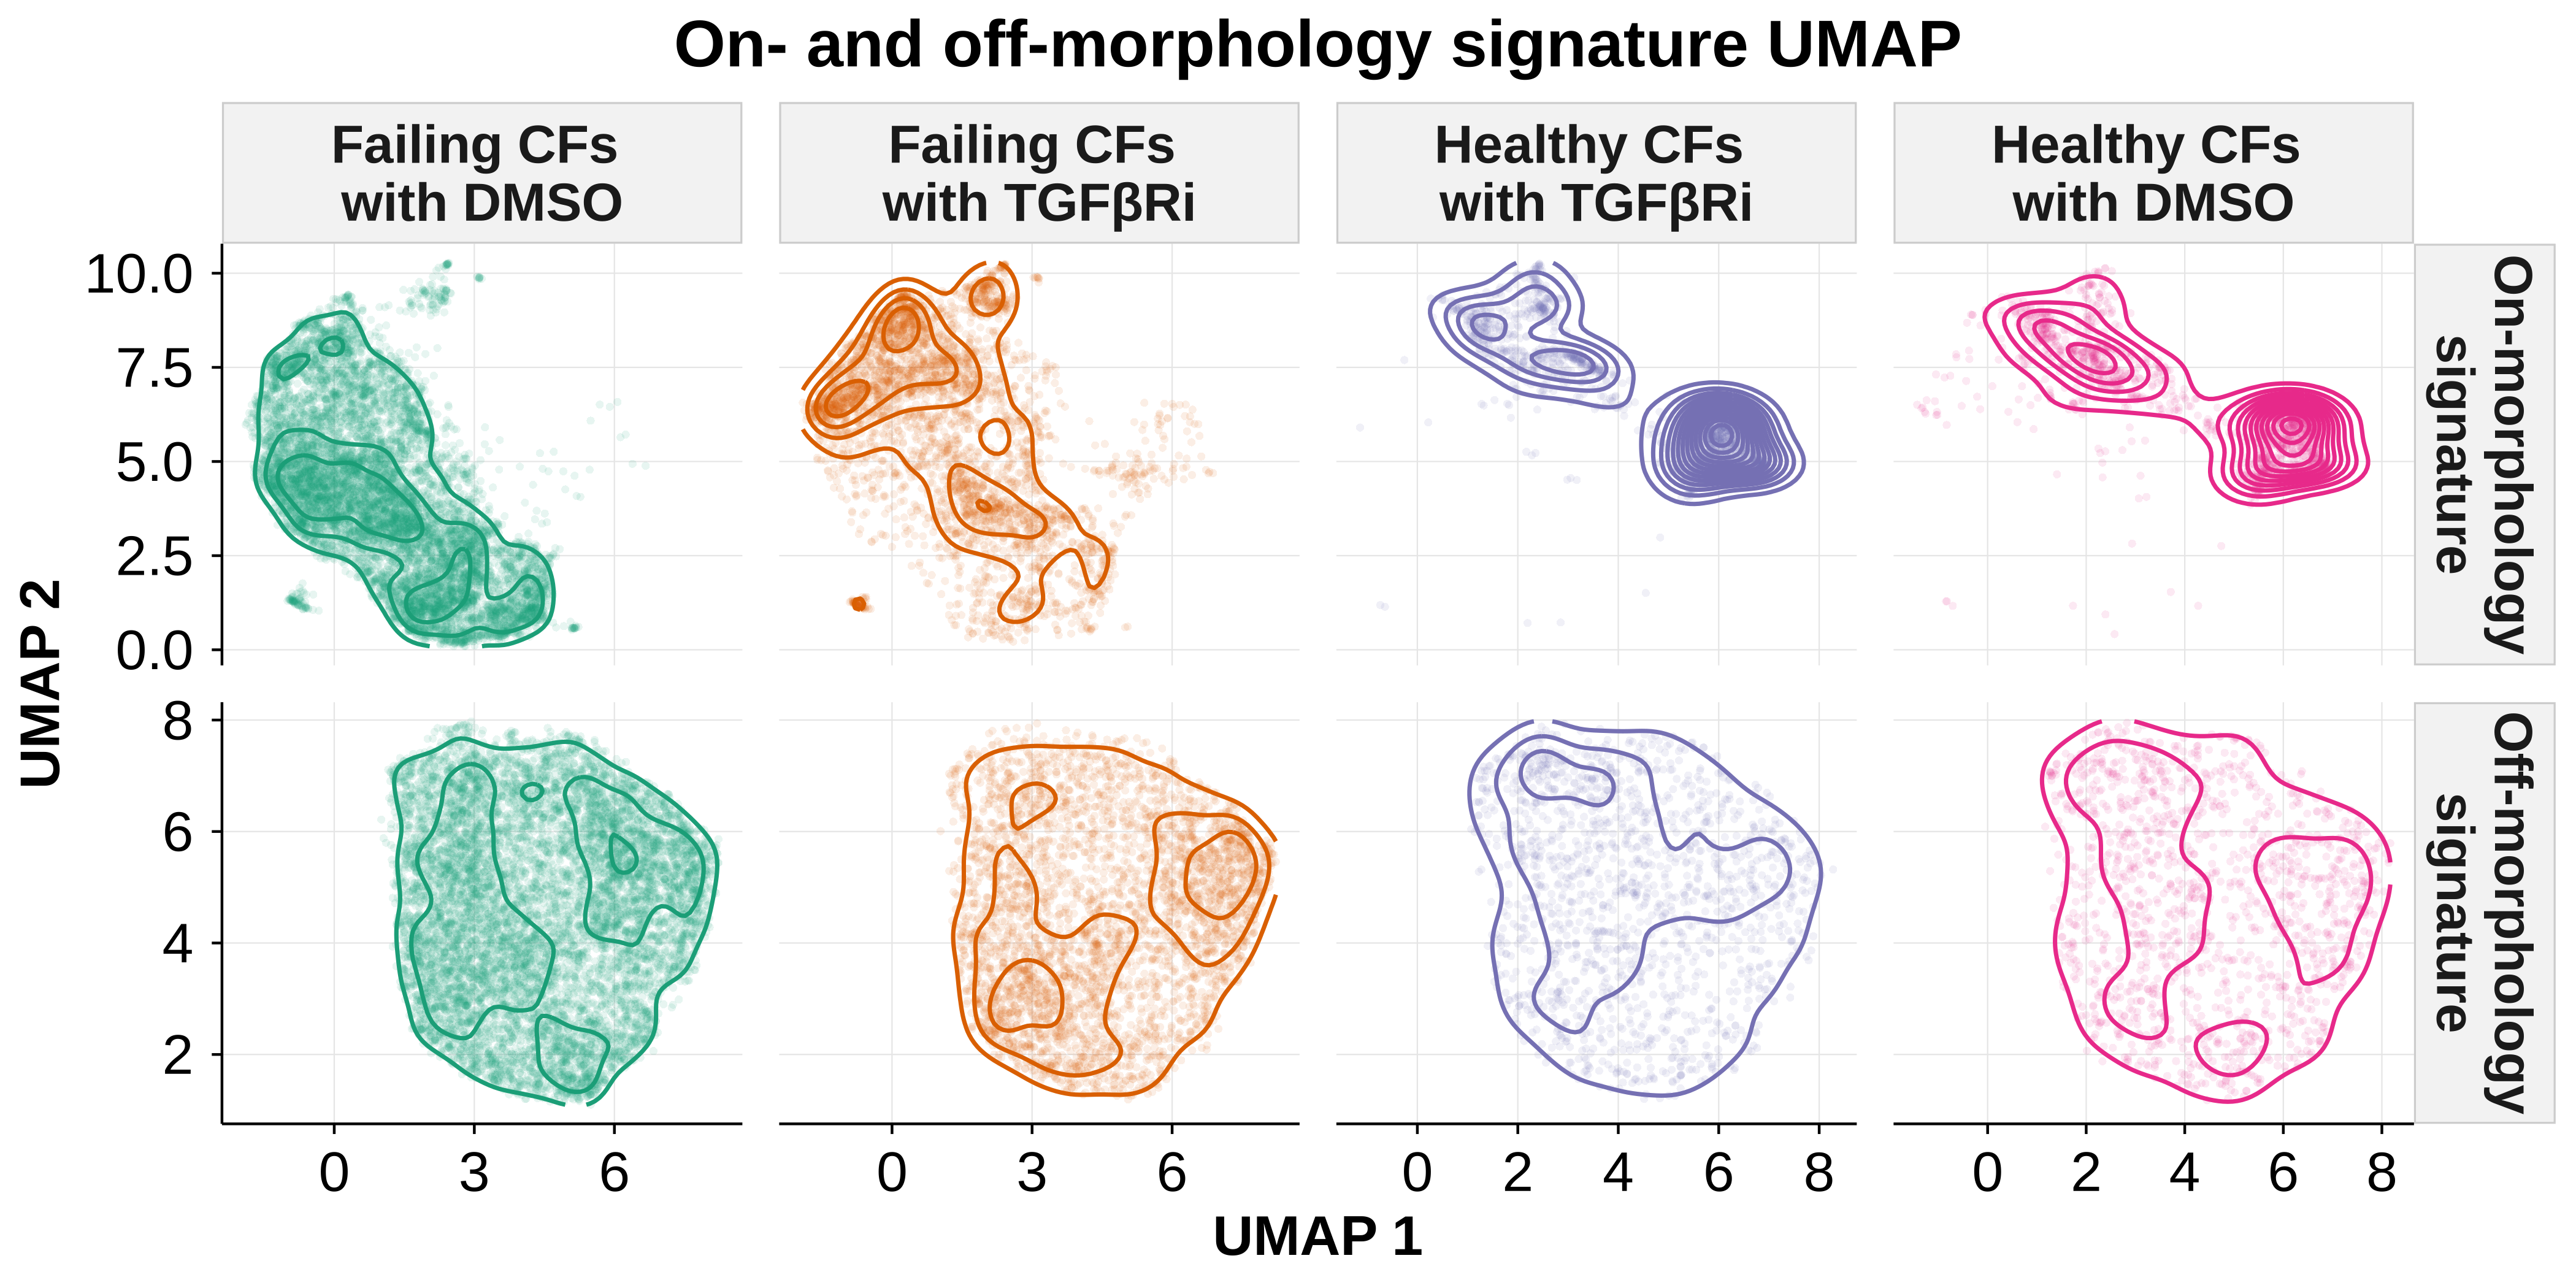

In [16]:
# notebook render option 
height <- 7
width <- 14
options(repr.plot.width = width, repr.plot.height = height, repr.plot.res = render_dpi)

# Prepare combined data with signature type for faceting
umap_on_contour_df <- umap_on_df %>% mutate(signature_type = "On-morph sig.")
umap_off_contour_df <- umap_off_df %>% mutate(signature_type = "Off-morph sig.")

umap_contour_df <- bind_rows(umap_on_contour_df, umap_off_contour_df) %>%
    mutate(
        signature_type = factor(signature_type, levels = c("On-morph sig.", "Off-morph sig.")),
        Metadata_perturbation = factor(Metadata_perturbation, levels = c("failing_DMSO", "failing_TGFRi", "healthy_TGFRi", "healthy_DMSO"))
    )

# Define facet label mappings
perturbation_labels <- c(
    failing_DMSO = "Failing CFs \nwith DMSO",
    failing_TGFRi = "Failing CFs \nwith TGFβRi",
    healthy_TGFRi = "Healthy CFs \nwith TGFβRi",
    healthy_DMSO = "Healthy CFs \nwith DMSO"
)

signature_type_labels <- c(
    "On-morph sig." = "On-morphology\nsignature",
    "Off-morph sig." = "Off-morphology\nsignature"
)

# Faceted contour plot: perturbation (columns) x signature_type (rows)
umap_contour_combined <- ggplot(umap_contour_df, aes(x = UMAP1, y = UMAP2, color = Metadata_perturbation)) +
    geom_point(alpha = 0.1, size = 1, shape = point_shape) +
    geom_density_2d(linewidth = 0.8, bins = 15) +
    scale_color_manual(values = color_palette, name = "Perturbation", labels = perturbation_labels) +
    facet_grid(
        signature_type ~ Metadata_perturbation,
        scales = "free",
        labeller = labeller(
            Metadata_perturbation = perturbation_labels,
            signature_type = signature_type_labels
        )
    ) +
    labs(
        title = "On- and off-morphology signature UMAP",
        x = "UMAP 1",
        y = "UMAP 2"
    ) +
    guides(color = guide_legend(override.aes = list(alpha = 1, size = 3, linewidth = 1.2))) +
    theme(
        strip.text = element_text(face = "bold", size = 21),
        axis.title = element_text(face = "bold", size = 22),
        axis.text = element_text(size = 22),
        legend.text = element_text(size = 21),
        legend.title = element_text(face = "bold", size = 22),
        panel.spacing = unit(1, "lines"),
        plot.title = element_text(face = "bold", size = 26, hjust = 0.5)
    )


# Save UMAP KDE contour plot
ggsave(
    filename = file.path(figures_dir, "umap_kde_contour_faceted.png"),
    plot = umap_contour_combined,
    width = width,
    height = height,
    dpi = render_dpi,
    bg = "white"
)

umap_contour_combined